       CREDIT CARD FRAUD DETECTION - MODEL EVAL

 Dataset Shape     : (5000, 6)
 Legitimate        : 4750 transactions
 Fraudulent        : 250 transactions
  Fraud Rate        : 5.0%

🔀 Training samples  : 4000
🧪 Testing samples   : 1000

              EVALUATION METRICS
Metric                 Log. Regression   Random Forest
-------------------------------------------------------
Accuracy                       0.9930          0.9920
Precision                      1.0000          0.9565
Recall                         0.8600          0.8800
F1-Score                       0.9247          0.9167

📋 Classification Report — Logistic Regression
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00       950
  Fraudulent       1.00      0.86      0.92        50

    accuracy                           0.99      1000
   macro avg       1.00      0.93      0.96      1000
weighted avg       0.99  

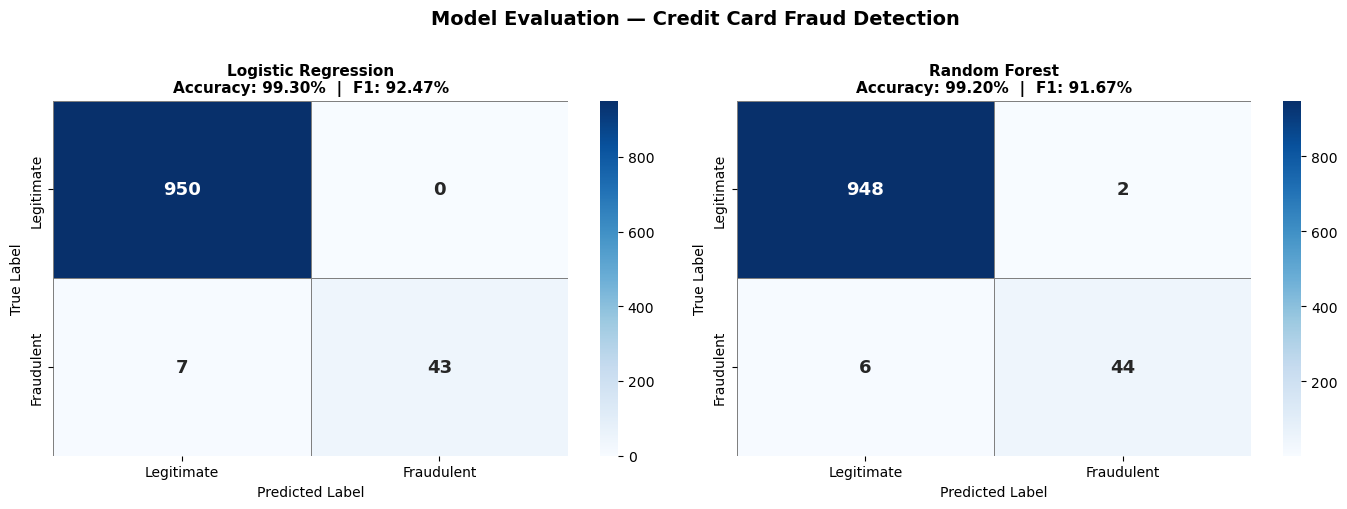


✅ Confusion matrix saved as 'confusion_matrices.png'


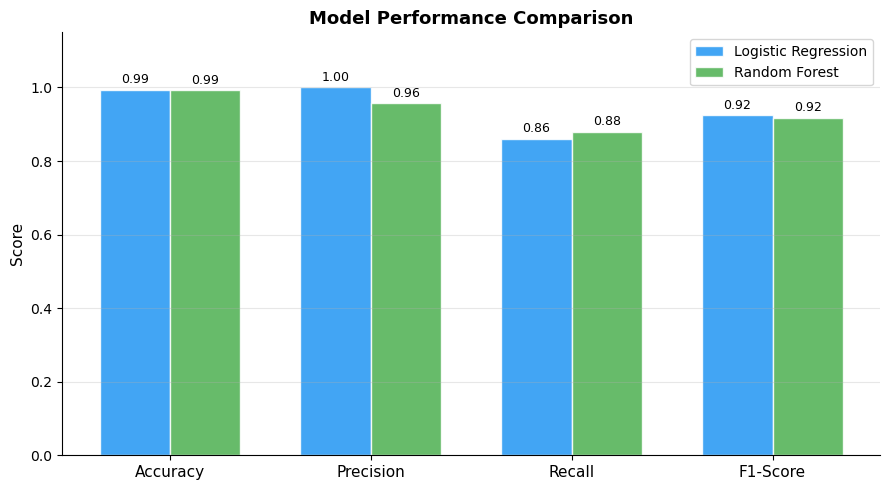

✅ Metrics chart saved as 'metrics_comparison.png'

🎉 Project complete!.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Loading Data
np.random.seed(42)
n_samples = 5000
n_fraud = 250  # ~5% fraud rate

# Legitimate transactions
legit = pd.DataFrame({
    'amount':    np.random.normal(100, 50, n_samples - n_fraud).clip(1),
    'hour':      np.random.randint(0, 24, n_samples - n_fraud),
    'v1':        np.random.normal(0, 1, n_samples - n_fraud),
    'v2':        np.random.normal(0, 1, n_samples - n_fraud),
    'v3':        np.random.normal(0, 1, n_samples - n_fraud),
    'Class':     0
})

# Fraudulent transactions (different pattern)
fraud = pd.DataFrame({
    'amount':    np.random.normal(300, 150, n_fraud).clip(1),
    'hour':      np.random.choice([0, 1, 2, 3, 23], n_fraud),  # late night fraud
    'v1':        np.random.normal(-3, 1.5, n_fraud),
    'v2':        np.random.normal(3, 1.5, n_fraud),
    'v3':        np.random.normal(-2, 1, n_fraud),
    'Class':     1
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=42)

print("=" * 55)
print("       CREDIT CARD FRAUD DETECTION - MODEL EVAL")
print("=" * 55)
print(f"\n Dataset Shape     : {df.shape}")
print(f" Legitimate        : {(df['Class'] == 0).sum()} transactions")
print(f" Fraudulent        : {(df['Class'] == 1).sum()} transactions")
print(f"  Fraud Rate        : {df['Class'].mean()*100:.1f}%\n")

# 3. FEATURES & TARGET 
X = df.drop('Class', axis=1)
y = df['Class']

# 4. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f" Training samples  : {len(X_train)}")
print(f" Testing samples   : {len(X_test)}\n")

#  5. SCALE FEATURES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 6. TRAIN MODELS 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
    }

# 7. PRINT METRICS TABLE 
print("=" * 55)
print("              EVALUATION METRICS")
print("=" * 55)
print(f"{'Metric':<20} {'Log. Regression':>17} {'Random Forest':>15}")
print("-" * 55)
metrics = ["accuracy", "precision", "recall", "f1"]
labels  = ["Accuracy", "Precision", "Recall", "F1-Score"]
for m, l in zip(metrics, labels):
    lr_val = results["Logistic Regression"][m]
    rf_val = results["Random Forest"][m]
    print(f"{l:<20} {lr_val:>16.4f} {rf_val:>15.4f}")
print("=" * 55)

# 8. CLASSIFICATION REPORTS 
for name, res in results.items():
    print(f"\n📋 Classification Report — {name}")
    print("-" * 55)
    print(classification_report(
        y_test, res["y_pred"],
        target_names=["Legitimate", "Fraudulent"]
    ))

# 9. VISUALISATIONS 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation — Credit Card Fraud Detection",
             fontsize=14, fontweight='bold', y=1.01)

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=["Legitimate", "Fraudulent"],
        yticklabels=["Legitimate", "Fraudulent"],
        linewidths=0.5, linecolor='gray',
        annot_kws={"size": 13, "weight": "bold"}
    )
    acc = res["accuracy"]
    f1  = res["f1"]
    ax.set_title(f"{name}\nAccuracy: {acc:.2%}  |  F1: {f1:.2%}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Confusion matrix saved as 'confusion_matrices.png'")

# ── 10. METRICS BAR CHART ────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
x      = np.arange(len(labels))
width  = 0.35
colors = ['#2196F3', '#4CAF50']

for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = ax2.bar(x + i * width, vals, width, label=name,
                   color=colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{v:.2f}", ha='center', va='bottom', fontsize=9)

ax2.set_title("Model Performance Comparison", fontsize=13, fontweight='bold')
ax2.set_xticks(x + width / 2)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Score", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics chart saved as 'metrics_comparison.png'")

print("\n🎉 Project complete!.")